In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sudhasreeyerramsetty","key":"d86bfcee1b5399f8e7c15fe2bde626de"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d awsaf49/brats2020-training-data

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [00:40<00:00, 180MB/s]



In [4]:
!unzip -q brats2020-training-data.zip

In [5]:
!ls

 BraTS2020_training_data      'BraTS20 Training Metadata.csv'
 brats2020-training-data.zip   sample_data


In [6]:
!ls BraTS2020_training_data/content/data | head

meta_data.csv
name_mapping.csv
survival_info.csv
volume_100_slice_0.h5
volume_100_slice_100.h5
volume_100_slice_101.h5
volume_100_slice_102.h5
volume_100_slice_103.h5
volume_100_slice_104.h5
volume_100_slice_105.h5


In [7]:
!pip install timm h5py
import pandas as pd

df = pd.read_csv("BraTS20 Training Metadata.csv")
df.head()

,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
0,../input/brats2020-training-data/BraTS2020_tra...,0,41,0,0,0,0,1.0
1,../input/brats2020-training-data/BraTS2020_tra...,0,41,1,0,0,0,1.0
2,../input/brats2020-training-data/BraTS2020_tra...,0,41,2,0,0,0,1.0
3,../input/brats2020-training-data/BraTS2020_tra...,0,41,3,0,0,0,1.0
4,../input/brats2020-training-data/BraTS2020_tra...,0,41,4,0,0,0,1.0


In [8]:
df['slice_path'] = df['slice_path'].apply(
    lambda x: x.replace(
        '../input/brats2020-training-data/',
        ''
    )
)

In [9]:
# loading a sample h5 file
import h5py

sample_path = df.iloc[0]['slice_path']

with h5py.File(sample_path, 'r') as f:
    image = f['image'][:]
    mask = f['mask'][:]

print(image.shape, mask.shape)

(240, 240, 4) (240, 240, 3)


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

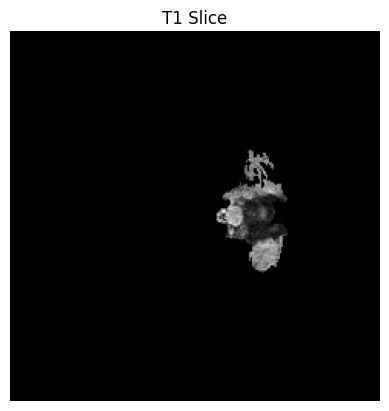

In [10]:
# visualize one slice
import matplotlib.pyplot as plt

plt.imshow(image[:, :, 0], cmap='gray')
plt.title("T1 Slice")
plt.axis('off')

In [11]:
# group slices by patient
df = df.sort_values(by=['volume', 'slice'])
patient_groups = df.groupby('volume')

In [12]:
patient_id = 1
patient_df = patient_groups.get_group(patient_id)

print(len(patient_df))

155


In [13]:
# build patient level label
import numpy as np

def get_patient_label(patient_df):
    NCR = int(patient_df['label1_pxl_cnt'].sum() > 0)
    ED  = int(patient_df['label2_pxl_cnt'].sum() > 0)
    ET  = int(patient_df['label0_pxl_cnt'].sum() > 0)
    return np.array([NCR, ED, ET])

In [14]:
import h5py
import cv2
import numpy as np

def load_and_preprocess_slice(path):
    with h5py.File(path, 'r') as f:
        img = f['image'][:]

    img = np.stack([
      cv2.resize(img[:, :, c], (224, 224))
      for c in range(4)
    ], axis=-1)

    img = img.astype(np.float32)
    for c in range(4):
        channel = img[:, :, c]
        channel = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
        img[:, :, c] = channel

    return img

In [15]:
# load all slices for one patient
def load_patient(patient_df):
    patient_df = patient_df.sort_values('slice').reset_index(drop=True)
    slices = []

    for path in patient_df['slice_path']:
        img = load_and_preprocess_slice(path)
        slices.append(img)

    slices = np.stack(slices)
    slices = np.transpose(slices, (0, 3, 1, 2))
    label = get_patient_label(patient_df)

    return slices, label

In [16]:
# test on one patient
patient_id = 1
patient_df = patient_groups.get_group(patient_id)

X, y = load_patient(patient_df)

print("Input shape:", X.shape)
print("Label:", y.shape)

Input shape: (155, 4, 224, 224)
Label: (3,)


In [17]:
# train-val split
from sklearn.model_selection import train_test_split

patient_ids = list(patient_groups.groups.keys())

train_ids, temp_ids = train_test_split(patient_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

print(len(train_ids), len(val_ids), len(test_ids))

258 55 56


In [18]:
# pytorch dataset
import torch
from torch.utils.data import Dataset

class BraTSDataset(Dataset):
    def __init__(self, df, patient_ids):
        self.df = df
        self.patient_ids = patient_ids
        self.groups = df.groupby('volume')

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]
        patient_df = self.groups.get_group(patient_id)

        X, y = load_patient(patient_df)

        return torch.tensor(X), torch.tensor(y, dtype=torch.float32)

In [19]:
# creating dataloaders
from torch.utils.data import DataLoader

train_dataset = BraTSDataset(df, train_ids)
val_dataset   = BraTSDataset(df, val_ids)
test_dataset = BraTSDataset(df, test_ids)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [20]:
# modifying vit for 4 channels
import timm
import torch
import torch.nn as nn

def create_vit_4ch():
    model = timm.create_model('vit_base_patch16_224', pretrained=True)

    old_conv = model.patch_embed.proj

    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None)
    )

    new_conv.weight.data[:, :3, :, :] = old_conv.weight.data
    new_conv.weight.data[:, 3, :, :] = old_conv.weight.data.mean(dim=1)

    model.patch_embed.proj = new_conv

    return model

In [21]:
# vit + mean pooling
class ViTMeanPooling(nn.Module):
    def __init__(self):
        super().__init__()

        self.vit = create_vit_4ch()
        self.vit.reset_classifier(0)

        for param in self.vit.parameters():
          param.requires_grad = True

        self.fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape

        chunk_size = 4

        all_features = []

        for i in range(0, S, chunk_size):
            x_chunk = x[:, i:i+chunk_size]

            b, s, c, h, w = x_chunk.shape
            x_chunk = x_chunk.reshape(b * s, c, h, w)

            with torch.no_grad():
              features = self.vit(x_chunk)

            features = features.view(b, s, -1)

            all_features.append(features)

        features = torch.cat(all_features, dim=1)

        # mean pooling
        pooled = features.mean(dim=1)

        out = self.fc(pooled)

        return out

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViTMeanPooling().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [23]:
# handling class imbalance
labels = []

for pid in train_ids:
    patient_df = patient_groups.get_group(pid)
    labels.append(get_patient_label(patient_df))

labels = np.array(labels)

pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts

pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [24]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [25]:
# training loop
!pip install tqdm

from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

    for X, y in tqdm(loader, desc="Training", leave=False):
        X = X.to(device).float()
        y = y.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type):
            outputs = model(X)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [26]:
# validation loop
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, y in tqdm(loader, desc="Validation", leave=False):
            X = X.to(device).float()
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [27]:
import os
os.makedirs("checkpoints", exist_ok=True)

def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss
    }, path)

In [28]:
num_epochs = 30

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        save_checkpoint(model, optimizer, epoch, val_loss, "checkpoints/best_model.pth")
        print("Model saved.")

    else:
        counter += 1
        print(f"No improvement. Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1
Train Loss: 0.0378
Val Loss: 0.0350
Model saved.


Epoch 2
Train Loss: 0.0370
Val Loss: 0.0347
Model saved.


Epoch 3
Train Loss: 0.0375
Val Loss: 0.0344
Model saved.


Epoch 4
Train Loss: 0.0365
Val Loss: 0.0343
Model saved.


Epoch 5
Train Loss: 0.0359
Val Loss: 0.0341
Model saved.


...

Epoch 26
Train Loss: 0.0332
Val Loss: 0.0328
Model saved.


Epoch 27
Train Loss: 0.0335
Val Loss: 0.0328
Model saved.


Epoch 28
Train Loss: 0.0342
Val Loss: 0.0328
Model saved.


Epoch 29
Train Loss: 0.0344
Val Loss: 0.0328
Model saved.


Epoch 30
Train Loss: 0.0344
Val Loss: 0.0328
Model saved.


In [29]:
checkpoint = torch.load("checkpoints/best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

ViTMeanPooling(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (a

In [30]:
# predictions
import torch

def get_predictions(model, loader, device):
    model.eval()

    all_targets = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device).float()
            y = y.to(device)

            outputs = model(X)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            all_targets.append(y.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

    all_targets = torch.cat(all_targets)
    all_probs = torch.cat(all_probs)
    all_preds = torch.cat(all_preds)

    return all_targets.numpy(), all_probs.numpy(), all_preds.numpy()

In [31]:
# classification report
from sklearn.metrics import classification_report, accuracy_score, f1_score

targets, probs, preds = get_predictions(model, test_loader, device)

print("Classification Report:")
print(classification_report(
    targets,
    preds,
    target_names=["NCR", "ED", "ET"]
))

# exact match accuracy
accuracy = accuracy_score(targets, preds)
print(f"\nAccuracy: {accuracy:.4f}")

# these are better metrics for multi label classification compared to accuracy
print("Macro F1:", f1_score(targets, preds, average='macro'))
print("Micro F1:", f1_score(targets, preds, average='micro'))

Classification Report:
              precision    recall  f1-score   support

         NCR       0.98      1.00      0.99        55
          ED       0.98      0.77      0.86        53
          ET       1.00      0.43      0.60        56

   micro avg       0.98      0.73      0.84       164
   macro avg       0.99      0.73      0.82       164
weighted avg       0.99      0.73      0.82       164
 samples avg       0.99      0.74      0.83       164


Accuracy: 0.1964
Macro F1: 0.8180496285759444
Micro F1: 0.8391608391608392


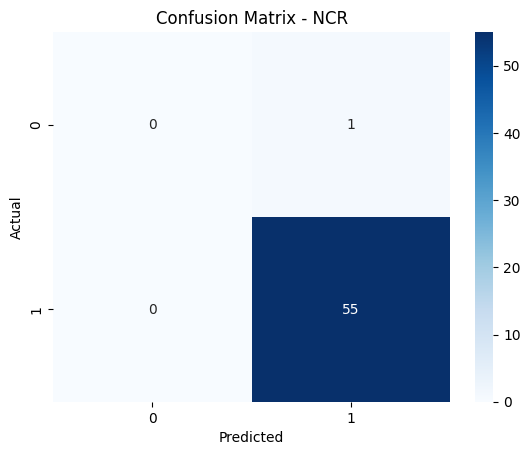

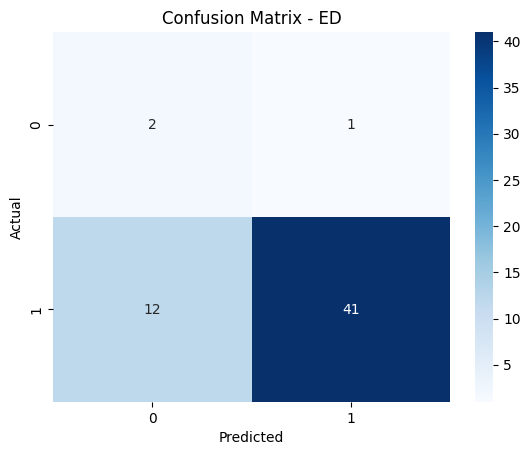

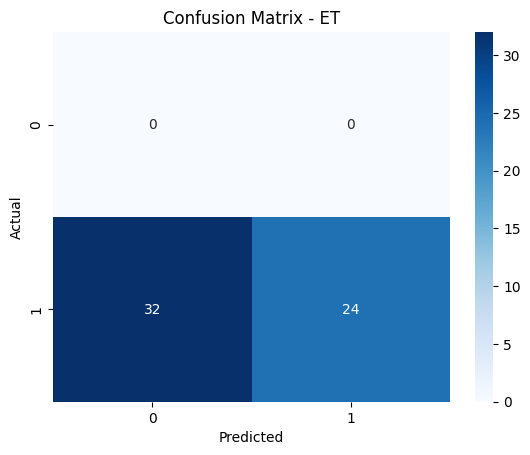

In [32]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["NCR", "ED", "ET"]

for i in range(3):
    cm = confusion_matrix(targets[:, i], preds[:, i])

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {labels[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Skipping ROC for ET (only one class present)


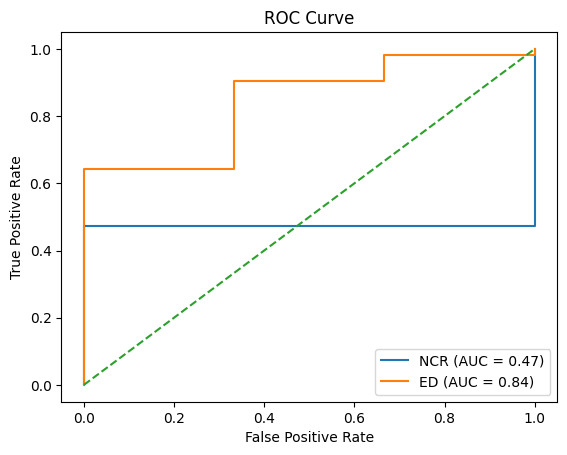

In [33]:
# NOTE: ROC and PR curves were computed only when both positive and negative samples were present for a class since these metrics are undefined otherwise

# roc-auc
from sklearn.metrics import roc_curve, auc

plt.figure()

for i, label in enumerate(["NCR", "ED", "ET"]):
    if len(np.unique(targets[:, i])) < 2:
        print(f"Skipping ROC for {label} (only one class present)")
        continue

    fpr, tpr, _ = roc_curve(targets[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Skipping PR curve for ET (only one class present)


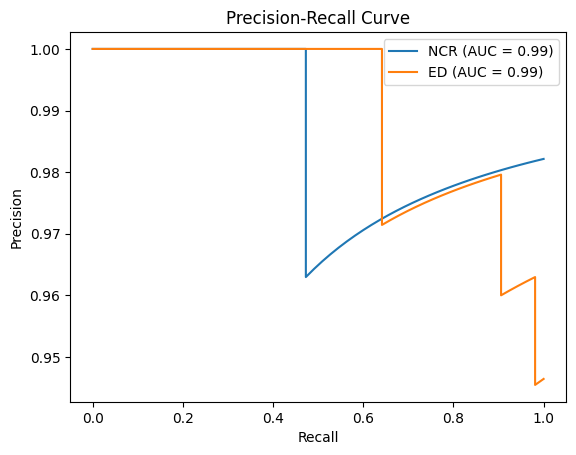

In [34]:
# pr-auc
from sklearn.metrics import precision_recall_curve, auc

plt.figure()

for i, label in enumerate(["NCR", "ED", "ET"]):
    if len(np.unique(targets[:, i])) < 2:
        print(f"Skipping PR curve for {label} (only one class present)")
        continue

    precision, recall, _ = precision_recall_curve(targets[:, i], probs[:, i])
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{label} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()